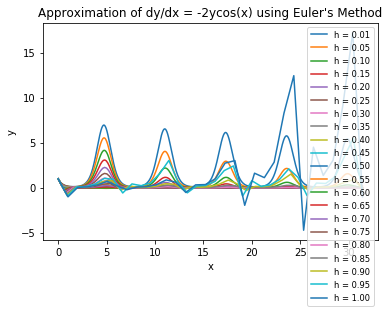

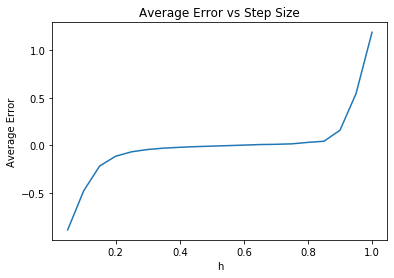

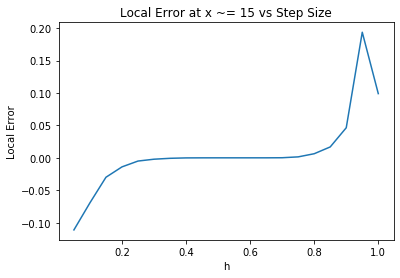

In [6]:
import numpy as np
import matplotlib.pyplot as plt

x_start, x_end = 0, 10 * np.pi

def defineParameters(h):
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    y_values[0] = 1 # y(0) = 1
    return num_steps, x_values, y_values

# Function representing dy/dx = -2y
def f(x, y):
    return -2 * y * np.cos(x)

def plot(x_values, y_values, h):
    plt.plot(x_values, y_values, label=f'h = {h:.2f}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f"Approximation of dy/dx = -2ycos(x) using Euler's Method")
    plt.legend(fontsize = 'small')

stepSize = np.arange(0, 1.05, 0.05)
stepSize[0] = .01
y_avg = np.zeros(len(stepSize))
y_local = np.zeros(len(stepSize))
for index, h in enumerate(stepSize):
    num_steps, x_values, y_values = defineParameters(h)
    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
    y_avg[index] = np.mean(y_values)
    idx = np.argmin(np.abs(x_values - 15))
    y_local[index] = y_values[idx]
    plot(x_values, y_values, h)
plt.show()

# Plotting average error
avgError = np.diff(y_avg)
plt.plot(stepSize[1:], avgError)
plt.xlabel('h')
plt.ylabel('Average Error')
plt.title('Average Error vs Step Size')
plt.show()

# Plotting local error
localError = np.diff(y_local)
plt.plot(stepSize[1:], localError)
plt.xlabel('h')
plt.ylabel('Local Error')
plt.title('Local Error at x ~= 15 vs Step Size')
plt.show()